In [1]:
import torch
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from datasets import load_dataset
from matplotlib import pyplot as plt
import random
import numpy as np
import time
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score

C:\Users\musae\Desktop\files\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 123

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Загрузка данных

In [4]:
ds = load_dataset('uoft-cs/cifar10')
ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [5]:
ds["train"].features

{'img': Image(mode=None, decode=True),
 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}

In [6]:
sample = ds["train"][0]
print(type(sample))
print(sample)

<class 'dict'>
{'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x2E7D8AC1E10>, 'label': 0}


In [7]:
class CifarDataset(Dataset):
    def __init__(self, data, transforms):
        self.data = data
        self.transforms = transforms
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]

        image = item['img']
        label = item['label']

        if self.transforms:
            image = self.transforms(image)
        return image, label

In [8]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [9]:
cifar10_train = CifarDataset(ds['train'], transforms=transform_train)

g = torch.Generator()
g.manual_seed(seed)

cifar10_loader_train = DataLoader(
    cifar10_train,
    batch_size=32,
    shuffle=True,
    generator=g
)

In [10]:
cifar10_test = CifarDataset(ds['test'], transforms=transform_test)

cifar10_loader_test = DataLoader(
    cifar10_test, 
    batch_size=128, 
    shuffle=False
)

# Создание модели

In [11]:
class GaussianActivationNoise(nn.Module):
    def __init__(self, sigma, relative):
        super().__init__()
        self.sigma = sigma
        self.relative = relative
    def forward(self, x):
        if not self.training or self.sigma == 0:
            return x
        
        noise = torch.randn_like(x)

        if self.relative:
            scale = x.detach().std()
            return x + self.sigma * scale * noise
        else:
            return x + self.sigma * noise

In [12]:
class Net(nn.Module):
    def __init__(self, sigma1=0, sigma2=0, sigma3=0, relative=True):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*64, 256),
            nn.ReLU(),
            GaussianActivationNoise(sigma3, relative),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)

        return x

# Шум параметров

In [13]:
def get_omega_for_parameter(name, omega1, omega2, omega3):
    if name.startswith('block1'):
        return omega1
    elif name.startswith('block2'):
        return omega2
    else:
        return omega3

# Обучение

In [14]:
num_epochs = 20
lr = 1e-2

In [15]:
criterion = nn.CrossEntropyLoss()

In [16]:
def evaluate(model, val_loader, final=False):
    model.eval()

    correct = 0
    running_loss = 0.0
    
    correct_pred = {i: 0 for i in range(10)}
    total_pred = {i: 0 for i in range(10)}

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)

            running_loss += loss.item()

            pred = output.argmax(dim=1)

            correct += pred.eq(target.data).sum()

            for label, prediction in zip(target, pred):
                label = label.item()
                prediction = prediction.item()
                if label == prediction:
                    correct_pred[label] += 1
    
                total_pred[label] += 1
                

    accuracy = correct / len(val_loader.dataset)
    avg_loss = running_loss / len(val_loader)

    if final:
        for i in range(10):
            acc = 100 * correct_pred[i] / total_pred[i]
            print(f"Accuracy class {i} = {acc:.1f} %")
        

    return accuracy.cpu().item(), avg_loss

In [17]:
def train(net, num_epochs, omega1, omega2, omega3, relative_params=True):
    losses = []
    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(cifar10_loader_train):
            data = data.to(device)
            target = target.to(device)
            
            optimizer.zero_grad()
    
            net_out = net(data)
            loss = criterion(net_out, target)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                for name, param in net.named_parameters():
                    if param.requires_grad:
                        omega = get_omega_for_parameter(name, omega1, omega2, omega3)
                        if omega > 0:
                            noise = torch.randn_like(param)

                            if relative_params:
                                scale = param.detach().std()
                                param.add_(omega * scale * noise)
                            else:
                                param.add_(omega * noise)
                
            running_loss += loss.item()
        if epoch == num_epochs-1: 
            val_acc, val_loss = evaluate(net, cifar10_loader_test, True)
        else:
            val_acc, val_loss = evaluate(net, cifar10_loader_test)
        losses.append(running_loss/len(cifar10_loader_train))
        print(f'epoch: {epoch+1}, train loss: {running_loss/len(cifar10_loader_train)}, val_acc: {val_acc}, val_loss: {val_loss}')

        plt.plot(losses)
        plt.xlabel("Эпоха")
        plt.ylabel("Loss");

epoch: 1, train loss: 1.8405581559802353, val_acc: 0.4635999798774719, val_loss: 1.4759050969836078
epoch: 2, train loss: 1.414731498033056, val_acc: 0.6326999664306641, val_loss: 1.0234780884996246
epoch: 3, train loss: 1.1667348677846612, val_acc: 0.6180999875068665, val_loss: 1.0424880159052112
epoch: 4, train loss: 1.0292008409535207, val_acc: 0.7236999869346619, val_loss: 0.7763458943065209
epoch: 5, train loss: 0.9438822819343073, val_acc: 0.7202999591827393, val_loss: 0.827009392690055
epoch: 6, train loss: 0.8715714361144424, val_acc: 0.758899986743927, val_loss: 0.7076778445817247
epoch: 7, train loss: 0.822390969716351, val_acc: 0.7748000025749207, val_loss: 0.657192466379721
epoch: 8, train loss: 0.7870404206631051, val_acc: 0.776199996471405, val_loss: 0.6397163294538667
epoch: 9, train loss: 0.7555637921344296, val_acc: 0.7813000082969666, val_loss: 0.6390292074861406
epoch: 10, train loss: 0.7280026252500079, val_acc: 0.7875999808311462, val_loss: 0.5946310011646415
epoch

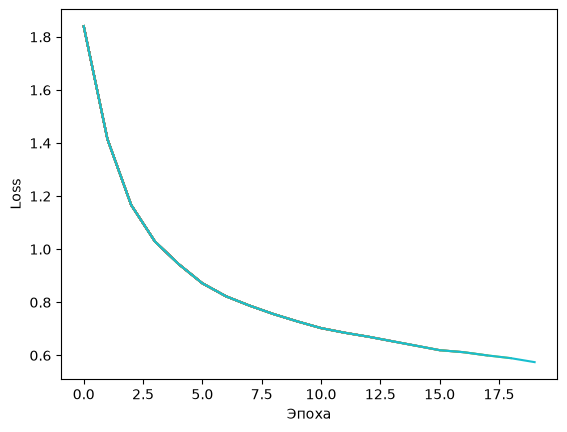

In [18]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.839547692165875, val_acc: 0.4804999828338623, val_loss: 1.3812309669542917
epoch: 2, train loss: 1.4176012780219411, val_acc: 0.6279000043869019, val_loss: 1.0328155484380601
epoch: 3, train loss: 1.173853377463035, val_acc: 0.6388999819755554, val_loss: 0.9865244385562365
epoch: 4, train loss: 1.038983324400828, val_acc: 0.7102000117301941, val_loss: 0.8226472327980814
epoch: 5, train loss: 0.9492025949294493, val_acc: 0.724399983882904, val_loss: 0.8025374985948394
epoch: 6, train loss: 0.8856547144614041, val_acc: 0.7561999559402466, val_loss: 0.7083428064479104
epoch: 7, train loss: 0.8341414576452356, val_acc: 0.7638999819755554, val_loss: 0.6848788661292836
epoch: 8, train loss: 0.7953419572675525, val_acc: 0.7652999758720398, val_loss: 0.6755245260045498
epoch: 9, train loss: 0.7634114956748996, val_acc: 0.7804999947547913, val_loss: 0.6295908576325525
epoch: 10, train loss: 0.7345381979559449, val_acc: 0.7896999716758728, val_loss: 0.6147953317135195
epo

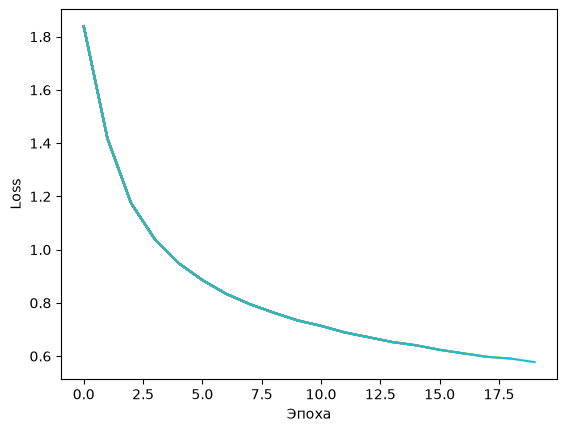

In [19]:
start = time.time()

net = Net(0, 0, 0.03)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 0)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8495642483730157, val_acc: 0.47540000081062317, val_loss: 1.387776964827429
epoch: 2, train loss: 1.4281655238823332, val_acc: 0.5852999687194824, val_loss: 1.174539942530137
epoch: 3, train loss: 1.1861022751604375, val_acc: 0.6717999577522278, val_loss: 0.9014653103261054
epoch: 4, train loss: 1.0384747454049261, val_acc: 0.715399980545044, val_loss: 0.809839791134943
epoch: 5, train loss: 0.9463942919643887, val_acc: 0.7429999709129333, val_loss: 0.7390196089503132
epoch: 6, train loss: 0.8758328560065247, val_acc: 0.7282999753952026, val_loss: 0.7700678004494196
epoch: 7, train loss: 0.8320410999630936, val_acc: 0.760699987411499, val_loss: 0.7036439829234835
epoch: 8, train loss: 0.7971656630989533, val_acc: 0.7610999941825867, val_loss: 0.6822013915339603
epoch: 9, train loss: 0.7619034625156065, val_acc: 0.7784000039100647, val_loss: 0.6288942170294025
epoch: 10, train loss: 0.7362969913260722, val_acc: 0.7666999697685242, val_loss: 0.6924493177027642
epo

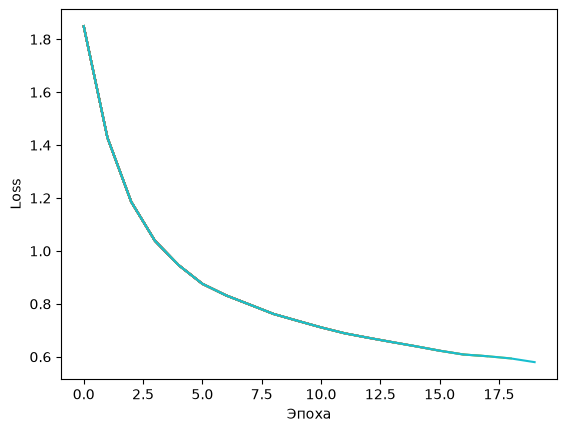

In [20]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 0, 0, 1e-3)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.9107034562569127, val_acc: 0.44419997930526733, val_loss: 1.476242768613598
epoch: 2, train loss: 1.5201969475068882, val_acc: 0.5770999789237976, val_loss: 1.1550682594504538
epoch: 3, train loss: 1.2281279936861855, val_acc: 0.6604999899864197, val_loss: 0.9327835606623299
epoch: 4, train loss: 1.0626620765458448, val_acc: 0.7033999562263489, val_loss: 0.8790412711191781
epoch: 5, train loss: 0.9631656757815099, val_acc: 0.7303999662399292, val_loss: 0.7546316724789294
epoch: 6, train loss: 0.8974698116706109, val_acc: 0.7342999577522278, val_loss: 0.7770431154890906
epoch: 7, train loss: 0.8381892322960071, val_acc: 0.7576000094413757, val_loss: 0.6965773015082637
epoch: 8, train loss: 0.7959248567153763, val_acc: 0.7623999714851379, val_loss: 0.6861568346053739
epoch: 9, train loss: 0.7654379237293053, val_acc: 0.7762999534606934, val_loss: 0.6630856440037112
epoch: 10, train loss: 0.7385724108053642, val_acc: 0.7802000045776367, val_loss: 0.6441625432123111

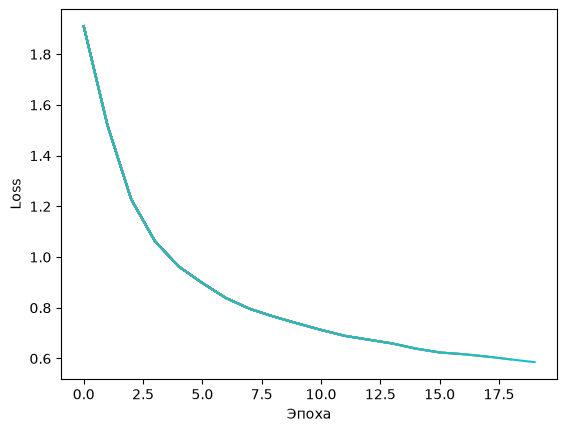

In [21]:
start = time.time()

net = Net(0.03, 0.03, 0.03)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

train(net, 20, 1e-4, 1e-4, 1e-4)

print('Время обучения', time.time() - start)